# Modèles de prévisions : Approche Hybride "Stress-Adjusted"

## Objectifs
**1. Contexte et Enjeux Scientifiques**
La prédiction du rendement agricole à l'échelle mondiale se heurte à une limite majeure :
- Les modèles purement climatiques (Météo -> Rendement) échouent à généraliser ($R^2 \approx 0.30$) car ils ne distinguent pas si une faible pluie est catastrophique (Maïs) ou acceptable (Sorgho).
- Les modèles purement physiques (Simulateurs) sont trop complexes et nécessitent des données de sol introuvables à l'échelle nationale.

**2. La Solution : Feature Engineering Agronomique (Inspiré de Shahhosseini et al., 2021)**
Plutôt que d'opposer Physique et IA, nous utilisons la connaissance agronomique pour créer des variables explicatives intelligentes. Comme démontré par *Shahhosseini et al. (2021)* sur le "Corn Belt", l'ajout de variables de stress simulées (Stress Hydrique, Stress Thermique) améliore drastiquement la performance des modèles de Machine Learning.

Ce notebook implémente une architecture en 3 étapes :

* **Étape 1 : Le "Moteur Agronomique" (Agronomy Engine)**
    * *Rôle :* Agir comme un expert FAO virtuel. Il ne prédit pas le rendement, mais quantifie les contraintes.
    * *Action :* Transformer les données brutes (Pluie mm, Temp °C) en indices biologiques ($Water\_Stress$, $Heat\_Stress$) basés sur les besoins spécifiques de chaque culture (Blé vs Maïs vs Riz).

* **Étape 2 : Modélisation "Stress-Adjusted"**
    * *Rôle :* Entraîner un modèle de Machine Learning (Random Forest) qui n'apprend plus par cœur les pays, mais apprend la **sensibilité** de chaque système agricole aux stress calculés.
    * *Hypothèse :* $Rendement = f(Technologie\_Pays, Stress\_Hydrique, Stress\_Thermique, Intrants)$.

* **Étape 3 : Évaluation Temporelle**
    * Validation rigoureuse sur le futur (Train < 2015, Test ≥ 2015) pour valider la robustesse de l'outil.
 
Ci-dessous, le schéma théorique validant notre approche de couplage (Coupling Strategy) :

![Architecture Hybride](img/schema_1.png)

---
**📚 Références Scientifiques**
1.  **Shahhosseini, M. et al. (2021).** *Coupling machine learning and crop modeling improves crop yield prediction*. Scientific Reports. (L'importance des variables de stress simulées).
2.  **FAO Irrigation and Drainage Paper No. 56.** (Standards pour les besoins en eau des cultures - Kc).

# 📋 PLAN D'ACTION : MODÉLISATION HYBRIDE (Notebook 03)

**Objectif :** Construire le "Teacher" (Simulateur Biophysique) et extraire la connaissance agronomique des données historiques pour l'injecter dans le modèle final.
**Entrées :** `dataset_teacher_historique.csv` & `dataset_student_fao.csv`.

---

## 🟢 PHASE 1 : INITIALISATION & SETUP

- [X] **1. Configuration de l'environnement**
  - [X] Imports des librairies (Pandas, Numpy, Sklearn, Matplotlib/Seaborn).
  - [X] **Configuration MLflow :** Définir l'expérience `Experiment_Agri_Hybrid_V1`.
  - [X] Chargement des datasets (Teacher et Student) nettoyés au notebook précédent.

- [X] **2. Vérification du Périmètre (Sanity Check)**
  - [X] S'assurer que le Teacher ne contient bien **que** les 4 cultures cibles (Wheat, Maize, Rice, Soybeans).
  - [X] Vérifier la présence des colonnes climatiques clés (`Temp`, `Rain`) dans les deux datasets.

---

## 🔵 PHASE 2 : EXTRACTION "DATA DRIVEN" (LE CERVEAU DU TEACHER)

- [ ] **3. Analyse des Optimums Climatiques**
  - [ ] *Objectif :* Demander aux données historiques les conditions idéales par culture.
  - [ ] **Méthode :** Discrétiser (Binning) les Températures et Pluies par tranches.
  - [ ] Calculer le rendement moyen du "Top 10%" des meilleures récoltes pour chaque tranche.
  - [ ] Identifier le pic : $T_{opt}$ (Température Optimale) et $R_{opt}$ (Pluie Optimale) pour chaque culture.

- [ ] **4. Sauvegarde des Paramètres**
  - [ ] Stocker ces constantes (ex: `OPTS = {'Wheat': {'temp': 15, 'rain': 600}...}`) pour les réutiliser plus tard.

---

## 🟠 PHASE 3 : INGÉNIERIE DU STRESS (FEATURE ENGINEERING)

- [ ] **5. Création des Features de Stress**
  - [ ] *Concept :* Transformer la donnée brute (25°C) en donnée métier (Stress Thermique).
  - [ ] **Calcul :** Appliquer la distance à l'optimum : $Stress = |Valeur_{Relevée} - Valeur_{Optimale}|$.
  - [ ] Appliquer ce calcul au Teacher (pour l'entraînement) ET au Student (pour la prédiction future).

---

## 🔴 PHASE 4 : ENTRAÎNEMENT DU MODÈLE "TEACHER"

- [ ] **6. Modélisation (Random Forest)**
  - [ ] **Target :** `Yield` (Rendement Historique).
  - [ ] **Features (X) :** Utiliser les indices de Stress calculés + Données de Sol (si dispos).
  - [ ] Split Train/Test sur l'historique.

- [ ] **7. Tracking & Évaluation**
  - [ ] Enregistrer le run dans MLflow (Paramètres, Métriques $R^2$, RMSE).
  - [ ] Vérifier si le modèle "comprend" la physique (ex: est-ce que le Stress fait bien baisser le rendement ?).

## Setup & Configuration

### Imports Librairies et Paths

In [1]:
## Imports et configuration
import pandas as pd
import numpy as np
import sys
import os
from pathlib import Path

# === CONFIGURATION PROJET ===
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# === SKLEARN - PREPROCESSING ===
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# === SKLEARN - METRIQUES ===
from sklearn.metrics import r2_score, mean_squared_error

# === SKLEARN - MODELES ===
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RandomizedSearchCV

# === SKLEARN - PCA ===
from sklearn.decomposition import PCA

# ===MLFlow === 
import mlflow
from mlflow.models.signature import infer_signature

# === GRAPHES === 
import matplotlib.pyplot as plt
import seaborn as sns

# === SAUVEGARDES === 
import joblib

from config.paths import DONNEES_PROCESSED
from config.config import RANDOM_STATE

### Config MLFlow

In [2]:
# Définition propre des chemins
# On s'assure que le dossier existe physiquement
artifact_path = project_root / "mlruns"
artifact_path.mkdir(parents=True, exist_ok=True)

# Conversionpour Windows (.as_uri())
# Cela va transformer "C:\Users\..." en "file:///C:/Users/..." automatiquement
tracking_uri = f"sqlite:///{project_root}/mlflow.db"
artifact_root = artifact_path.as_uri() 

# Connexion à la DB
mlflow.set_tracking_uri(tracking_uri)

In [3]:
# Création de l'expérience
experiment_name = "Agri_Hybrid_Shahhosseini_V1"

# On vérifie d'abord si elle existe pour éviter le try/catch aveugle
current_experiment = mlflow.get_experiment_by_name(experiment_name)

if current_experiment is None:
    # Elle n'existe pas, on la crée avec le bon chemin d'artefacts
    print(f"Création de l'expérience {experiment_name}...")
    exp_id = mlflow.create_experiment(
        name=experiment_name,
        artifact_location=artifact_root
    )
else:
    # Elle existe, on récupère son ID
    print(f"L'expérience {experiment_name} existe déjà.")
    exp_id = current_experiment.experiment_id

# 5. Activation
mlflow.set_experiment(experiment_name)
mlflow.sklearn.autolog(log_models=True, log_input_examples=True)

print(f"✅ MLflow connecté : Expérience '{experiment_name}' (ID: {exp_id}) active.")
print(f"📂 Artefacts configurés sur : {artifact_root}")

2026/03/02 12:19:01 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/03/02 12:19:01 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/03/02 12:19:01 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/03/02 12:19:01 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/03/02 12:19:01 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/03/02 12:19:01 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/03/02 12:19:04 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/02 12:19:04 INFO mlflow.store.db.utils: Updating database tables
2026/03/02 12:19:04 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/03/02 12:19:04 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/03/02 12:19:06 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/03/02 12:19:06 INFO alembic.runtime

L'expérience Agri_Hybrid_Shahhosseini_V1 existe déjà.
✅ MLflow connecté : Expérience 'Agri_Hybrid_Shahhosseini_V1' (ID: 2) active.
📂 Artefacts configurés sur : file:///C:/Users/Fab/Documents/P12_systeme_reco_agriculture/mlruns


## PHASE 1 : TEACHER MODEL
Apprentissage des lois agronomiques sur le dataset Historique.

### Chargement du dataset et vérifications

In [4]:
# Chargement du dataset
df_teacher = pd.read_csv(DONNEES_PROCESSED / "dataset_teacher_historique.csv")

In [5]:
df_teacher.columns

Index(['Region', 'Soil_Type', 'Crop', 'Rainfall_mm', 'Temperature_Celsius',
       'Fertilizer_Used', 'Irrigation_Used', 'Weather_Condition',
       'Days_to_Harvest', 'Yield_tons_per_hectare'],
      dtype='object')

In [6]:
df_teacher['Crop'].unique()

array(['Rice', 'Soybean', 'Wheat', 'Maize'], dtype=object)

In [7]:
df_teacher.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
1,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
2,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251
3,South,Silt,Soybean,797.471182,37.704974,False,True,Rainy,74,5.898416
4,West,Clay,Wheat,357.902357,31.593431,False,False,Rainy,90,2.652392


In [8]:
df_teacher.describe()

,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,666494.000000,666494.000000,666494.000000,666494.000000
mean,550.196393,27.501418,104.502954,4.650693
std,259.735002,7.218034,25.956466,1.695130
min,100.005750,15.000068,60.000000,0.000411
25%,325.304597,21.253656,82.000000,3.421291
50%,550.707826,27.503431,105.000000,4.652829
75%,774.674725,33.740153,127.000000,5.877401
max,999.998098,39.999997,149.000000,9.963372


**Note Méthodologique : Approche Hybride & Extraction de Connaissances**

**Contexte (Shahhosseini et al., 2021) :**
Cette architecture repose sur l'intégration de connaissances agronomiques pour guider le modèle de Machine Learning. Au lieu d'utiliser un simulateur biophysique externe (comme APSIM), nous adoptons une approche **"Data-Driven Teacher"**.

**Stratégie d'Extraction des Paramètres ($T_{opt}$, $Rain_{opt}$) :**
Plutôt que d'imposer des seuils théoriques rigides, nous allons extraire les optimums physiologiques directement depuis le dataset historique (le "Teacher") qui contient la vérité biophysique simulée.
* **Méthode :** Discrétisation (Binning) des variables climatiques et analyse des déciles supérieurs (Top 10% des rendements) pour identifier les pics de performance.
* **Avantage :** Les seuils sont adaptés spécifiquement à la distribution de nos données d'entraînement.

**Validation Bibliographique (Sanity Check) :**
Les optimums extraits empiriquement seront confrontés à la cohérence des standards internationaux pour s'assurer de la robustesse biologique du modèle :
* *Besoins Hydriques :* FAO Irrigation and Drainage Paper No. 56 (Allen et al., 1998).
* *Seuils Thermiques :* FAO EcoCrop Database (Hackett, 1988).

### Extraction "Data Driven"

#### Discrétisation des températures et des pluies

In [9]:
# 1. Binning Températures
df_teacher['Temp_Bin'] = df_teacher.Temperature_Celsius.round(decimals=0)

# 2. Binning Pluie (Tranches de 50mm)
# On crée des bornes de 0 à 1100 (pour couvrir largement le max de 999)
bins_rain = range(0, 1100, 50)

# pd.cut va découper la colonne en tranches
df_teacher['Rain_Bin'] = pd.cut(df_teacher['Rainfall_mm'], bins=bins_rain)

# 3. Vérification visuelle
print("Aperçu du découpage Pluie :")
print(df_teacher[['Rainfall_mm', 'Rain_Bin']].head())

Aperçu du découpage Pluie :
   Rainfall_mm     Rain_Bin
0   992.673282  (950, 1000]
1   986.866331  (950, 1000]
2   730.379174   (700, 750]
3   797.471182   (750, 800]
4   357.902357   (350, 400]


#### Extraction

⏳ Calcul des profils de réponse...


C:\Users\Fab\AppData\Local\Temp\ipykernel_15292\3496010782.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby(['Crop', bin_col])[value_col].mean().reset_index()


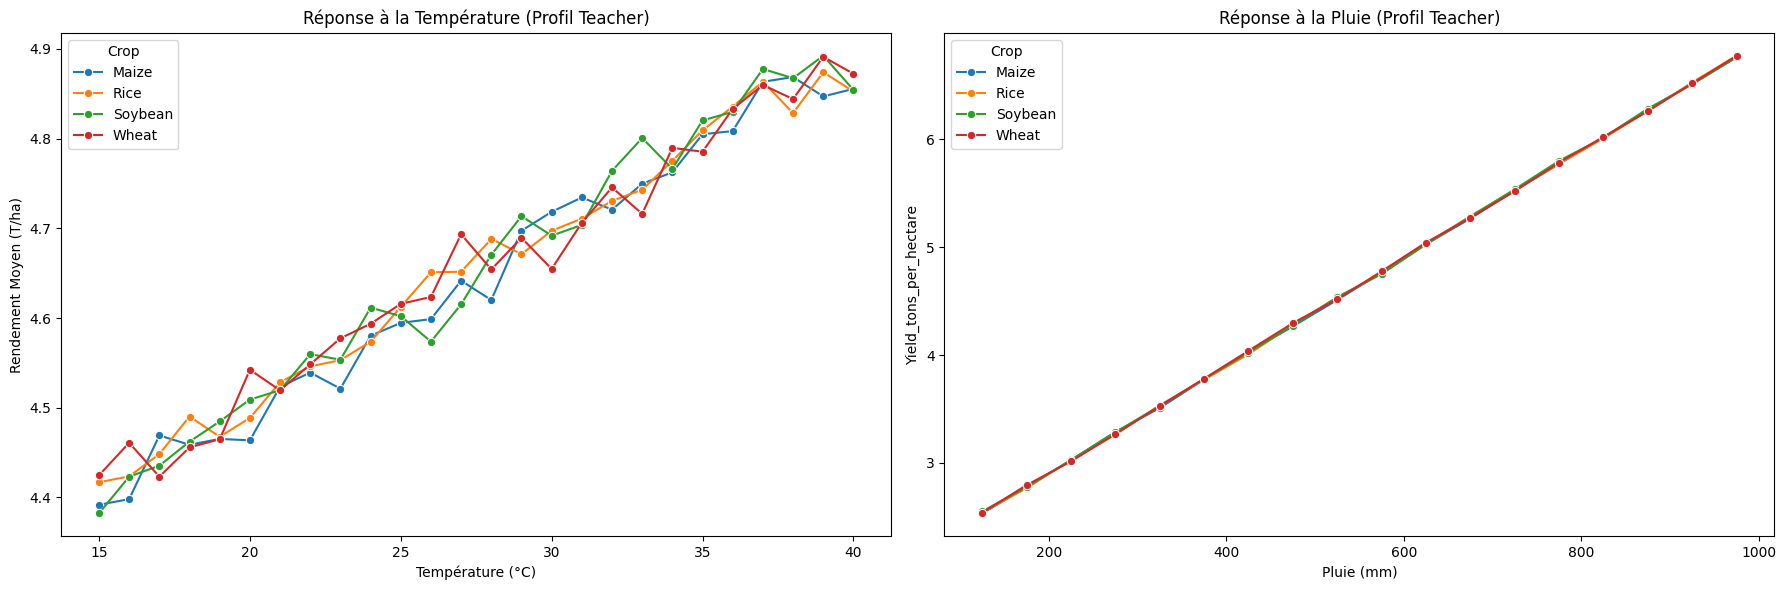

In [10]:
# Fonction pour calculer les stats par bin
def get_optimums(df, bin_col, value_col='Yield_tons_per_hectare'):
    # On groupe par Culture et par Tranche (Bin)
    # On calcule la moyenne du rendement
    stats = df.groupby(['Crop', bin_col])[value_col].mean().reset_index()
    return stats

# 1. Calcul des courbes de réponse
print("⏳ Calcul des profils de réponse...")
temp_profiles = get_optimums(df_teacher, 'Temp_Bin')
rain_profiles = get_optimums(df_teacher, 'Rain_Bin')

# 2. Visualisation (Indispensable pour valider la physique)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Graphique Température
sns.lineplot(data=temp_profiles, x='Temp_Bin', y='Yield_tons_per_hectare', hue='Crop', ax=axes[0], marker='o')
axes[0].set_title("Réponse à la Température (Profil Teacher)")
axes[0].set_ylabel("Rendement Moyen (T/ha)")
axes[0].set_xlabel("Température (°C)")

# Graphique Pluie
# Astuce : Pour l'axe X, on veut le milieu de l'intervalle, pas le texte "(950, 1000]"
# On crée une colonne temporaire 'Rain_Center' pour l'affichage
rain_profiles['Rain_Center'] = rain_profiles['Rain_Bin'].apply(lambda x: x.mid)

sns.lineplot(data=rain_profiles, x='Rain_Center', y='Yield_tons_per_hectare', hue='Crop', ax=axes[1], marker='o')
axes[1].set_title("Réponse à la Pluie (Profil Teacher)")
axes[1].set_xlabel("Pluie (mm)")

plt.tight_layout()
plt.show()

✅ Colonne Sol trouvée : 'Soil_Type'
   -> Valeurs : ['Clay' 'Sandy' 'Silt' 'Peaty' 'Chalky' 'Loam']


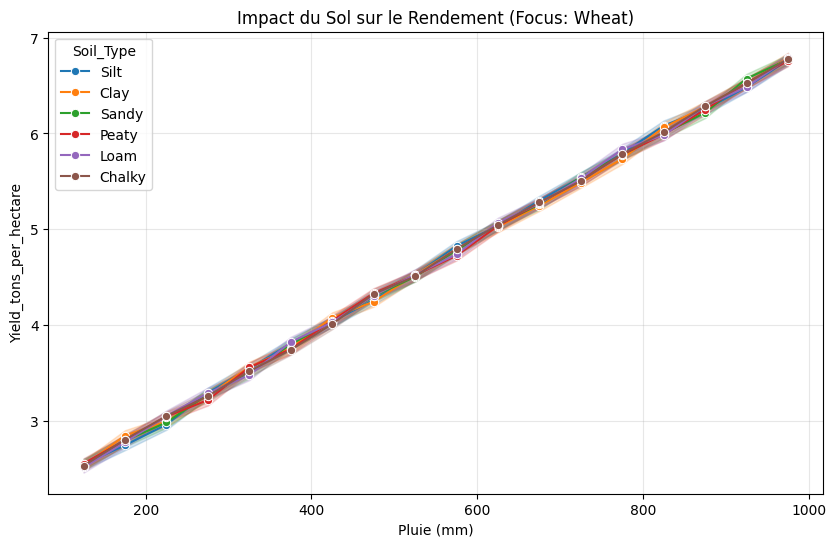

In [11]:
# ==============================================================================
# AUDIT DU SOL : EST-CE QUE ÇA COMPTE ?
# ==============================================================================

# 1. On vérifie d'abord si la colonne existe
col_sol = None
for col in ['Soil_Type', 'Soil', 'soil_type']: # On cherche le nom probable
    if col in df_teacher.columns:
        col_sol = col
        break

if col_sol:
    print(f"✅ Colonne Sol trouvée : '{col_sol}'")
    print(f"   -> Valeurs : {df_teacher[col_sol].unique()}")

    # 2. Le Test Visuel (Hue = Sol)
    plt.figure(figsize=(10, 6))
    
    # On reprend notre Rain_Bin calculé juste avant
    # On utilise 'Rain_Center' pour l'axe X (si tu ne l'as pas calculé, je le remets ici)
    df_teacher['Rain_Center'] = df_teacher['Rain_Bin'].apply(lambda x: x.mid)
    
    # On filtre sur une seule culture (ex: Wheat) pour ne pas brouiller la vue
    subset = df_teacher[df_teacher['Crop'] == 'Wheat']
    
    sns.lineplot(
        data=subset, 
        x='Rain_Center', 
        y='Yield_tons_per_hectare', 
        hue=col_sol,  # C'est ici que la magie opère
        marker='o'
    )
    
    plt.title(f"Impact du Sol sur le Rendement (Focus: Wheat)")
    plt.xlabel("Pluie (mm)")
    plt.grid(True, alpha=0.3)
    plt.show()

else:
    print("❌ Aucune colonne de type 'Sol' trouvée dans le dataset Teacher.")
    print("   -> Colonnes dispos :", df_teacher.columns.tolist())

In [12]:
df_teacher.Crop.unique()

array(['Rice', 'Soybean', 'Wheat', 'Maize'], dtype=object)

In [ ]:
# ==============================================================================
# 1. DÉFINITION DE LA CONNAISSANCE MÉTIER (PARAMÈTRES FAO)
# ==============================================================================
# Dictionnaire des besoins physiologiques par culture
# Sources : FAO Water (Crop Water Information) & ECOCROP
# - rain_opt_min/max : Plage de précipitation optimale (mm/an)
# - temp_opt_min/max : Plage de température optimale (°C)
# - temp_crit_high : Seuil de stress thermique sévère (échaudage)

CROP_PARAMS = {
    'Wheat':      {'rain_opt': 550,  'temp_opt_min': 15, 'temp_opt_max': 25, 'temp_crit': 30},
    'Maize':      {'rain_opt': 650,  'temp_opt_min': 20, 'temp_opt_max': 30, 'temp_crit': 35},
    'Rice':       {'rain_opt': 1000, 'temp_opt_min': 22, 'temp_opt_max': 32, 'temp_crit': 36},
    'Soybean':   {'rain_opt': 500,  'temp_opt_min': 20, 'temp_opt_max': 30, 'temp_crit': 35}
}

# Valeurs par défaut pour les cultures inconnues (Moyenne générique)
DEFAULT_PARAMS = {'rain_opt': 700, 'temp_opt_min': 20, 'temp_opt_max': 30, 'temp_crit': 35}

# ==============================================================================
# 2. LE MOTEUR AGRONOMIQUE (CORRIGÉ & ROBUSTE)
# ==============================================================================

def calculate_agronomic_stress(row):
    
    """Calcule les indices de stress basés sur la culture et le climat local.
    Compatible avec les colonnes Teacher (Rainfall_mm) et Student (Rain_Cycle)."""
    
    # 1. Gestion des noms de colonnes (Harmonisation)
    # On cherche 'Crop' (Teacher) ou 'Item' (Student)
    crop = row.get('Crop', row.get('Item', 'Unknown')) 
    
    # On cherche 'Rainfall_mm' (Teacher) ou 'Rain_Cycle' (Student)
    rain = row.get('Rainfall_mm', row.get('Rain_Cycle'))
    
    # On cherche 'Temperature_Celsius' (Teacher) ou 'Temp_Cycle' (Student)
    temp = row.get('Temperature_Celsius', row.get('Temp_Cycle'))
    
    # Sécurité : Si une donnée manque, on renvoie NaN ou 0
    if pd.isna(rain) or pd.isna(temp):
        return pd.Series([np.nan, np.nan], index=['Water_Stress', 'Heat_Stress'])

    # 2. Récupération des paramètres de la culture
    params = CROP_PARAMS.get(crop, DEFAULT_PARAMS)
    
    # --- A. CALCUL DU STRESS HYDRIQUE (Water Stress) ---
    # Formule : Écart relatif à l'optimum
    
    delta_rain = rain - params['rain_opt']
    
    if delta_rain < 0:
        # Manque d'eau (Sécheresse)
        w_stress = abs(delta_rain) / params['rain_opt']
    else:
        # Trop d'eau (Asphyxie racinaire) - Impact réduit de moitié (0.5)
        w_stress = (delta_rain / params['rain_opt']) * 0.5
        
    # Cap à 1.0
    w_stress = min(w_stress, 1.0)

    # --- B. CALCUL DU STRESS THERMIQUE (Heat Stress) ---
    h_stress = 0.0
    
    # Trop froid
    if temp < params['temp_opt_min']:
        h_stress = (params['temp_opt_min'] - temp) / 10 
        
    # Trop chaud (Stress modéré)
    elif temp > params['temp_opt_max']:
        h_stress = (temp - params['temp_opt_max']) / 10
        
        # Trop chaud (Stress Critique / Echaudage)
        if temp > params['temp_crit']:
            h_stress *= 2.0 # Pénalité doublée
            
    # Cap à 1.0
    h_stress = min(h_stress, 1.0)
    
    return pd.Series([w_stress, h_stress], index=['Water_Stress', 'Heat_Stress'])
    
# ==============================================================================
# 3. APPLICATION SUR LE DATASET
# ==============================================================================
print("🚜 Démarrage du Moteur Agronomique...")

# Application de la fonction (peut prendre quelques secondes)
# Assure-toi que df_teacher contient bien 'Item' (ou Crop), 'Rain_Cycle' et 'Temp_Cycle'
df_enriched = df_teacher.copy()
stress_cols = df_enriched.apply(calculate_agronomic_stress, axis=1)
df_enriched = pd.concat([df_enriched, stress_cols], axis=1)



🚜 Démarrage du Moteur Agronomique...


In [ ]:
print("✅ Enrichissement terminé.")
print("\nAperçu des nouvelles variables agronomiques :")
print(df_enriched[['Crop', 'Rainfall_mm', 'Temperature_Celsius', 'Water_Stress', 'Heat_Stress']].sample(10))

# Petit check visuel immédiat
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_enriched['Water_Stress'], bins=20, color='blue', kde=True)
plt.title("Distribution du Stress Hydrique Global")

plt.subplot(1, 2, 2)
sns.histplot(df_enriched['Heat_Stress'], bins=20, color='red', kde=True)
plt.title("Distribution du Stress Thermique Global")
plt.show()

**Le Water Stress (Escalier descendant) :** montre que la majorité des cultures dans le dataset historique sont dans des conditions pluviométriques "acceptables". Le modèle va donc apprendre à détecter les exceptions (les années de sécheresse, à droite du graphe).

**Heat Stress (Distribution Bimodale en U) :** Soit tout va bien (Stress $\approx 0$).Soit on dépasse le seuil critique (Stress $\approx 1$, la barre rouge à droite).C'est un comportement binaire (Vie ou Mort) typique des vagues de chaleur.

### Briques du pipeline

In [ ]:
# 1. Variables Numériques
NUM_VARS = ['Rainfall_mm', 'Temperature_Celsius', 'Water_Stress', 'Heat_Stress']

# 2. Variables Catégorielles
CAT_VARS = ['Soil_Type', 'Crop']

# 3. Variables Booléennes
BOOL_VARS = ['Fertilizer_Used', 'Irrigation_Used']

# 4. Cible
TARGET = 'Yield_tons_per_hectare'

In [ ]:
# Pipeline numérique : Nettoyer (Moyenne) et Scaler (Standardisation)
# Important pour mettre Rain/Temp (grandes valeurs) au même niveau que les Stress (0-1)
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Pipeline catégoriel : Nettoyer (Mode) et Encoder (OneHot)
# Gère Soil_Type et Crop
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Pipeline booléen : Encoder (Vrai/Faux -> 1/0)
# Gère Fertilizer et Irrigation
bool_pipeline = Pipeline([   
    ('ordinal', OrdinalEncoder())
])

# Assemblage Final
preprocessor_teacher = ColumnTransformer([
    ('num', num_pipeline, NUM_VARS),
    ('cat', cat_pipeline, CAT_VARS),
    ('bool', bool_pipeline, BOOL_VARS)
], remainder='drop') # On laisse tomber Region et Weather volontairement

print("✅ Préprocesseur Teacher configuré.")

### Fonction d'expérimentation des modèles

In [ ]:
def train_model(model_class, params, run_name, X, y, preprocessor_obj):
    """
    Entraîne un modèle avec suivi MLflow.
    Args:
        preprocessor_obj : Le pipeline de preprocessing créé juste avant (Teacher ou Student)
    """
    # Split (Pour le Teacher, un random split est OK car la physique ne change pas dans le temps)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
    
    with mlflow.start_run(run_name=run_name):
        # 1. Création du pipeline complet
        model = model_class(**params)
        
        full_pipeline = Pipeline([
            ('preprocessor', preprocessor_obj), # On utilise l'objet passé en argument
            ('regressor', model)
        ])

        # 2. Entraînement
        print(f"⚙️ Entraînement de {run_name}...")
        full_pipeline.fit(X_train, y_train)
        
        # 3. Prédictions & Métriques
        y_pred = full_pipeline.predict(X_test)
        
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        # Log manuel des métriques (en plus de l'autolog par sécurité)
        mlflow.log_metric("test_r2", r2)
        mlflow.log_metric("test_rmse", rmse)
        
        print(f"✅ Terminé. R²: {r2:.4f} | RMSE: {rmse:.2f}")

        # 4. Signature & Sauvegarde
        signature = infer_signature(X_test, y_pred)
        mlflow.sklearn.log_model(full_pipeline, "model", signature=signature)

        return full_pipeline

In [ ]:
# Feature + target
features_teacher = NUM_VARS + CAT_VARS + BOOL_VARS
X_teacher = df_enriched[features_teacher]
y_teacher = df_enriched[TARGET]

### Exécution et analyse rapide des résultats

In [ ]:
# Configuration du Random Forest (Paramètres robustes par défaut)
rf_params = {
    'n_estimators': 100,
    'max_depth': 12,        # Pas trop profond pour garder de la généralité
    'random_state': RANDOM_STATE,
    'n_jobs': -1
}

# Lancement
teacher_pipeline = train_model(
    model_class=RandomForestRegressor,
    params=rf_params,
    run_name="Teacher_Model_Physics_V1",
    X=X_teacher,
    y=y_teacher,
    preprocessor_obj=preprocessor_teacher
)

In [ ]:
# Création du dossier models s'il n'existe pas
save_path = DONNEES_PROCESSED.parent / "models"
os.makedirs(save_path, exist_ok=True)

# Sauvegarde avec un nouveau nom pour distinguer la V2 (Physique) de la V1 (Old)
model_name = "teacher_model_v2_physics.pkl"
joblib.dump(teacher_pipeline, save_path / model_name) # Utilise la variable 'teacher_pipeline'

print(f"💾 Modèle V2 (Physics) sauvé ici : {save_path / model_name}")